###  Spectral lines from ionizing and recombining hydrogen plasma

2024.2.2   k.i.   
2024.2.7   k.i., u.k.   
2024.2.14  k.i., u.k.    include Ne, Nh, Te, Ntot in SE  
2024.3.18  k.i.,    add r1,rc calc  z
2024.3.29  k.i., u.k.   make new hydrogen model  
2024.12.20  t.o., k.i.  IdxI = nl-1, IdxJ = nu-1  
2025.2.25  k.i.  Balmer & Paschen line intensities  
2026.4.11  k.u., k.i.   Atom.init_theoretical_hydrogen_atom_(nLevel=nLevel)

In [102]:
#from IPython.core.display import display, HTML
#display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2

from spectra.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [103]:
from spectra.ImportAll import *
from spectra.Struct import Atom, Atmosphere, Radiation
from spectra.Atomic import Collision, SEsolver, ContinuumOpacity, BasicP
from spectra.Util.HelpUtil import help_
from spectra.Visual import Plotting  #, Grotrian
from spectra.Atomic import LTELib, Hydrogen
from spectra.Function.SEquil import SELib
from spectra.Util.AtomUtils.AtomInfo import level_info, extract_lprof, each_prof, line_list
from spectra import Constants as Cst
from spectra.Function.SlabModel import CloudModel

## Initialize H-atom

In [146]:
import os
######  make hydrogen atom #####
#from spectra.Util.AtomicDataUtils import MakeTheoreticalHydrogenLevels as mh
#conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H6.conf" )  ; H_nam ='H'
#conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H_theory.conf" )  ; H_nam ='H'
#conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H34a.conf" )  ; H_nam ='H'
#atom, wMesh, path_dict = Atom.init_Atom_(conf_path , is_hydrogen=True)
atom, wMesh, path_dict = Atom.init_theoretical_hydrogen_atom_(nLevel=15)
                                                # nLevel # of bound-levels + 1 (continuum)

#help_(atom)
#print(atom.Level['erg'])
#help_(wMesh)
#path_dict
# Balmer series
ii = np.where(wMesh.Line_Coe['idxI'] == 1) ; print(wMesh.Line_Coe['w0'][ii]*1e8)


[6564.69838343 4862.73858968 4341.72991059 4102.93513188 3971.23612552
 3890.19026144 3836.51085511 3799.01433694 3771.73973678 3751.25565162
 3735.4667585  3723.03386768]


### Solar spectrum array

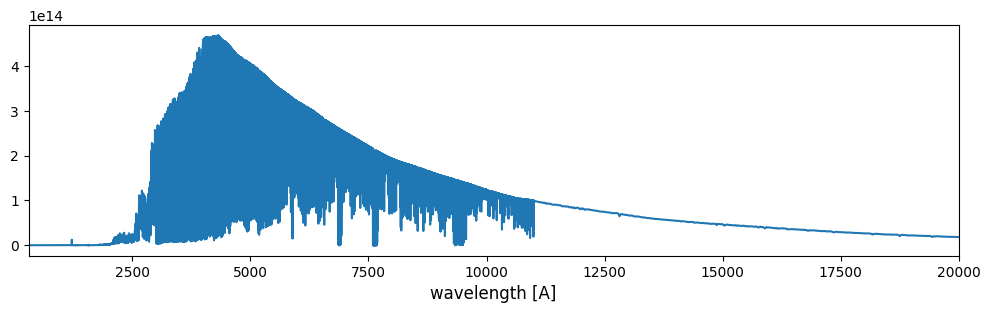

In [147]:
#  prepare solar radiation spectrum
import copy
Vd = 0.
Vt = 5e5          #   cm/s
depth = 1E1* 1.E5 #   km *1e5 -> cm  very thin

atmos = Atmosphere.Atmosphere0D(Nh=1.E12, Ne=1.E11, Te=7.E3, Vd=Vd, Vt=Vt) # create a class
solar_spec  = Radiation.init_Radiation_(atmos, wMesh)
# it looks better to separate solar spectrum and PI_intensity, calc PI intensity in SE**??
# wl incomplete information of PI_intensity, better to be combined with wMech of atom
wls = solar_spec.backRad[0,:]*1E8   
wls_air = BasicP.vacuum_to_air_(wls,'AA')   # wavelength in air of background solar spectrum [A]
Isolar = solar_spec.backRad[1,:].copy()   # background solar spectrum intensity    "    [erg/cm^3/s/str]

#  for photo-excitation, mean intensity gets half of the backgroud solar spectrum
solar_spec.backRad[1,:] *= 0.5            # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec.PI_intensity[:,:] *= 0.5       # solar spectrum mean intensity    "    [erg/cm^3/s/str]

fig, ax = plt.subplots(1,1, figsize=(12,3), dpi=100)
ax.plot(wls_air, Isolar)
#ax.set_xlim(6560, 6570)
ax.set_xlim(300, 20000)
#ax.set_xlim(10820, 10840) ; ax.set_ylim(0,1.2e14)
#ax.set_yscale("log") ; ax.set_ylim(1e7,1e15)
ax.set_xlabel("wavelength [A]", fontsize=12)
plt.show()

def solspec(solar_spec,Jfactor=1):
    ssp = copy.deepcopy(solar_spec)
    ssp.backRad[1,:] *= Jfactor     
    ssp.PI_intensity[:,:] *= Jfactor
    return(ssp)


In [149]:
help_(solar_spec)
help_(atmos)
solar_spec.PI_intensity[0,:]

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Radiation
|- backRad                 ndarray                              s: (2, 3754678)
|- PI_intensity            ndarray                              s: (14, 41)
------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atmosphere0D
|- Nh                      float                                v: 1000000000000.0
|- Ne                      float                                v: 100000000000.0
|- Te                      float                                v: 7000.0
|- Vd                      float                          

array([2.45306194e+09, 1.95108976e+09, 1.78704098e+09, 1.72501591e+09,
       1.56512145e+09, 1.32348814e+09, 1.02626297e+09, 8.52454692e+08,
       6.94941184e+08, 4.53087857e+08, 3.78238410e+08, 5.89389194e+08,
       2.46262205e+08, 1.93856070e+08, 1.68422192e+08, 1.33396154e+08,
       1.02492272e+08, 7.43675618e+07, 7.20422073e+07, 4.71382643e+07,
       2.76067295e+07, 5.59282548e+07, 6.33628944e+07, 6.69030104e+07,
       4.78170293e+07, 2.65470368e+08, 1.03693449e+08, 3.43742335e+07,
       2.72256544e+07, 5.12986323e+08, 1.94508243e+08, 1.12968118e+08,
       1.30880646e+08, 5.83047567e+08, 1.59608920e+08, 1.42608969e+09,
       1.21854333e+09, 1.06484561e+09, 1.18935047e+09, 1.91830264e+09,
       3.40347741e+08])

In [152]:
help_(wMesh)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Wavelength_Mesh
|- Cont_mesh               ndarray                              s: (14, 41)
|- Cont_Coe                struct array                         s: (14,)
  |-  idxI                 int64                                s: (14,)
  |-  idxJ                 int64                                s: (14,)
  |-  w0                   float64                              s: (14,)
  |-  nLambda              int64                                s: (14,)
|- Line_mesh               ndarray                              s: (3731,)
|- Line_mesh_idxs          ndarray                              s: (91, 2)
|- Line_absorb_prof        ndarray                              s: (3731,)
|- Line_Coe                struct array                 

## Atomic process
##### 
$$\frac{dn_i}{dt}= 
\sum\limits_{j>i}A_{ji}n_j + \sum\limits_{j \ne i} B_{ji} J_\lambda n_j + P_{ci} n_c 
+ \sum\limits_{j \ne i} C_{ji}n_e n_j + C_{ci} n_e n_c \\
\quad -\left[ \sum\limits_{j<i}{A_{ij}} + \sum\limits_{j \ne i} B_{ij} J_\lambda + P_{ic} J_\lambda 
+ \sum\limits_{j\ne i}{C_{ij}} n_e +  C_{ic}  n_e \right]n_i \\
= R_{\nu i} n_\nu + C_{\nu i} n_\nu \qquad [\rm{cm^{-3}s^{-1}(flux)}, \quad \nu = 1,2,,,N,c] $$

######
$$
\begin{bmatrix}
T_{[N,0]} & & & & T_{[N,N]}\\
\vdots & & & & :\\
\vdots & & & & :\\
T_{[1,0]} & T_{[1,1]} & & & :\\
T_{[0,0]} & T_{[0,1]}& & & T_{[0,N]}\\
\end{bmatrix}
=
\begin{bmatrix}
c←1 & \cdots & \rm{電離} & \cdots & 0\\
: & \rm{励起}& & 0 & \vdots \\
: &  &   ／ & & 再結合 \\ 
2←1 & 0 & & \rm{脱励起} & 2←c&\\
0 & 1←2 & & \cdots & 1←c\\
\end{bmatrix}
$$


### Einstein's $A$ 係数
#### $$𝐴_{𝑛_𝑢 𝑛_𝑙}=\frac{𝛼𝑅_𝑦}{𝑚𝑐^2}  \frac{2^6}{3\sqrt3} \frac{1}{𝜏_{𝑛_𝑢}n_l(𝑛_u^2 − n_l^2)}  𝑔_{𝑏𝑏}$$
##### $$𝑅_𝑦=\frac{𝑚𝑒^4}{2ℏ^2}, 𝑎_0=\frac{ℏ^2}{𝑚𝑒^2}, 𝛼≡\frac{𝑒^2}{ℏ𝑐}, 𝜏_𝑛=𝑛^3  \frac{ℎ}{2𝑅_𝑦}$$
Fujimoto 2004 より


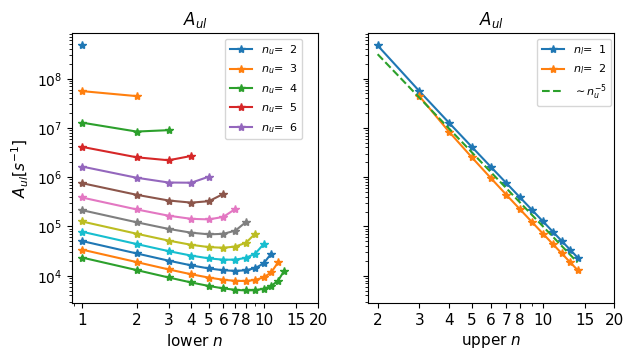

In [106]:
#------- display Aji  -------
Aji = np.array(atom.Line['AJI'])
idxI = np.array(atom.Line['idxI']) # lower level
idxJ = np.array(atom.Line['idxJ']) # upper level
n_lev = np.size(atom.Level)-1
n_line = len(Aji)
nus = np.arange(2,n_lev+1,dtype='int') #  upper n

fig, axs = plt.subplots(1,2, figsize=(7,3.5), dpi=100, sharey=True)

ax=axs[0]  #---  Aji vs. n_l
for n_u in nus:
    ii = np.where((idxI+1 < n_u) & (idxJ+1 == n_u))
    if n_u < 7:
        ax.plot(idxI[ii]+1,Aji[ii],"-*", label="$n_u$={0:3d}".format(n_u))
    else:
        ax.plot(idxI[ii]+1,Aji[ii],"-*")
ax.set_title('$A_{ul}$', fontsize=12)
plt.tick_params(labelsize=11)
ax.set_xscale("log")
ax.set_yscale("log")
ticpos = [1,2,3,4,5,6,7,8,10,15,20]
ticlab = ticpos
ax.set_xticks(ticpos)
ax.set_xticklabels(ticlab, fontsize=11)
ax.set_xlabel("lower $n$", fontsize=11)
ax.set_ylabel("$A_{ul} [s^{-1}]$ ", fontsize=11)
ax.legend(bbox_to_anchor=(0.6,1),fontsize=8,ncol=1)

ax=axs[1]  #---  Aji vs. n_u
for n_l in [1,2]:
    ii = np.where((idxJ+1 > n_l) & (idxI+1 == n_l))
    ax.plot(idxJ[ii]+1,Aji[ii],"-*", label="$n_l$={0:3d}".format(n_l))

ax.plot(nus,1./nus**5 *1e10, '--',label='$\sim n_u^{-5}$')
ax.set_title('$A_{ul}$', fontsize=12)
plt.tick_params(labelsize=11)
ax.set_xscale("log")
ax.set_yscale("log")
ticpos = [2,3,4,5,6,7,8,10,15,20]
ticlab = ticpos
ax.set_xticks(ticpos)
ax.set_xticklabels(ticlab, fontsize=11)
ax.set_xlabel("upper $n$", fontsize=11),
ax.legend(bbox_to_anchor=(1.01,1),fontsize=8,ncol=1)


## Transition rate

In [107]:
# transition heat map
def heatmap(ax, mat,vmin=None, vmax=None, title='', colbar=0, last=''):
    
    nmax = len(mat)-1
    norm = LogNorm(vmin, vmax, clip=True)
    im = ax.imshow( mat, origin="lower", cmap='cool', norm=norm, aspect='equal' )
    if last == 'c':
        ticklab = [i+1 for i in range(nmax)]+['c']
    else:
        ticklab = [i+1 for i in range(nmax+1)]
    ax.set_xticks([i for i in range(nmax+1)])
    ax.set_xticklabels(ticklab, fontsize=10)
    ax.set_xlabel('$n_j$', fontsize=15)
    ax.set_yticks([i for i in range(nmax+1)])
    ax.set_yticklabels(ticklab, fontsize=10)
    ax.set_ylabel('$n_i$', fontsize=15)
    ax.set_title(title,fontsize=13)

    # colorbar
    if colbar != 0:
        cax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
        fig.colorbar( im, cax=cax, orientation='vertical',label=colbar)
    
    return None


In [108]:
from spectra.Atomic import Cmat_Hydrogen as ch
# Statistical Eq. in a given [$T_e,n_e$]
Te = 10000.
Ne = 1*1e11
Jfactor = 0.5   # factor for solar radiation

ssp = solspec(solar_spec,Jfactor=Jfactor)
slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
Rmat = Rate.Rmat
Cmat = Rate.Cmat
Cmat2 = ch.Cmat_HI_Theoretical(atom.nLevel,Te,Ne)

#help_(slab)
#help_(SE)
#help_(Rate)
#help_(slab)


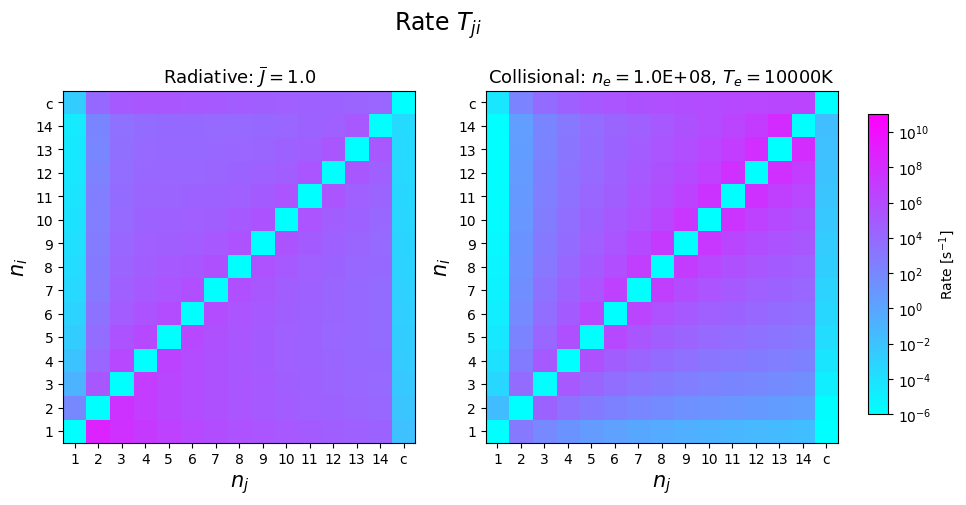

In [113]:
#--- transition rate map ----------------------------------------
vmin = 1e-6 ;  vmax = 1e11
#vmin = None ;  vmax = None

fig, axs = plt.subplots(1,2, figsize=(10,5), dpi=100)#, sharey=True)
title='Radiative: '+r"$\overline{J}=$"+f"{Jfactor:3.1F}"
heatmap(axs[0], Rmat, title=title,vmin=vmin,vmax=vmax, last='c')
title='Collisional: '+r"$n_e=$"+f"{SE.Ne:5.1E}, "+r"$T_e=$"+f"{SE.Te:5.0f}K"
heatmap(axs[1], Cmat, title=title,vmin=vmin,vmax=vmax, colbar='Rate [s$^{-1}$]', last='c')
plt.suptitle("Rate $T_{ji}$", fontsize=17, y=1.01)

plt.show()


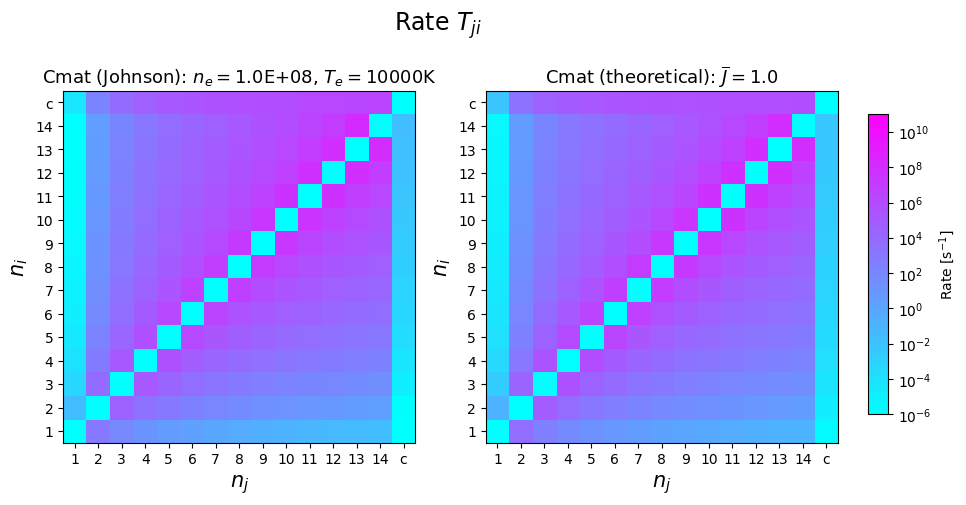

In [114]:
#  Cmat from theoretical foemula in Fujimoto 2004

fig, axs = plt.subplots(1,2, figsize=(10,5), dpi=100)#, sharey=True)
title='Cmat (Johnson): '+r"$n_e=$"+f"{SE.Ne:5.1E}, "+r"$T_e=$"+f"{SE.Te:5.0f}K"
heatmap(axs[0], Cmat, title=title,vmin=vmin,vmax=vmax, last='c')
title='Cmat (theoretical): '+r"$\overline{J}=$"+f"{Jfactor:3.1F}"
heatmap(axs[1], Cmat2, title=title,vmin=vmin,vmax=vmax, colbar='Rate [s$^{-1}$]', last='c')
plt.suptitle("Rate $T_{ji}$", fontsize=17, y=1.01)

plt.show()


C:\Users\ichim\AppData\Local\Temp\ipykernel_28120\141748762.py:4: RuntimeWarning: invalid value encountered in divide
  heatmap(ax, Cmat2/Cmat, title='Cmat(theor.)/Cmat(Johnson)', vmin=0.1, vmax=2, colbar='Rate [s$^{-1}$]', last='c')


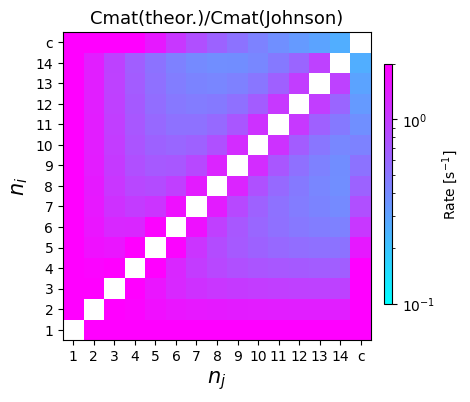

In [115]:
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=100)

title='Cmat (Johnson): '+r"$n_e=$"+f"{SE.Ne:5.1E}, "+r"$T_e=$"+f"{SE.Te:5.0f}K"
heatmap(ax, Cmat2/Cmat, title='Cmat(theor.)/Cmat(Johnson)', vmin=0.1, vmax=2, colbar='Rate [s$^{-1}$]', last='c')


i=20
#ax.plot(Cmat[i,:],'.',label='Johnson')
#ax.plot(Cmat2[i,:],'*',label='Theoretical')
#ax.set_yscale('log')
#ax.legend(bbox_to_anchor=(1.01,1),fontsize=10,ncol=1)

plt.show()

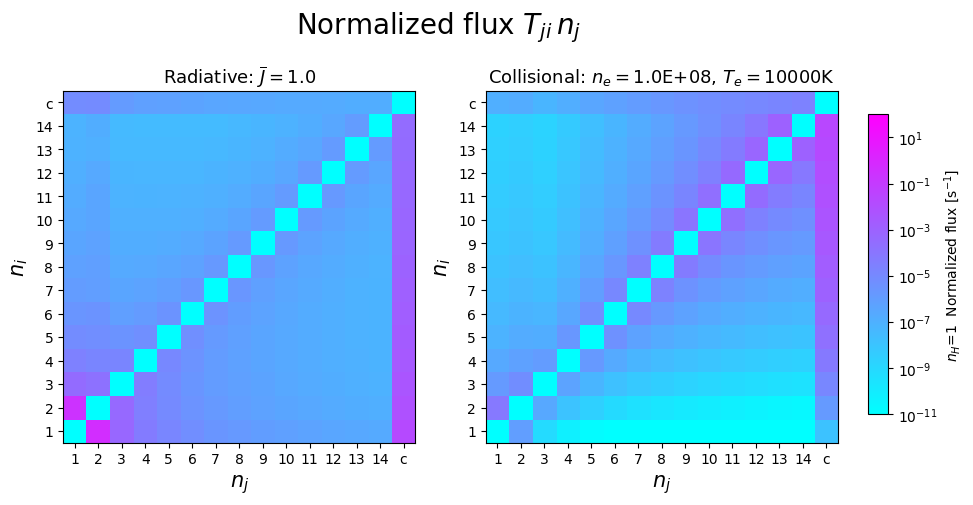

In [116]:
vmin = 1e-11 ;  vmax = 1e2
fig, axs = plt.subplots(1,2, figsize=(10,5), dpi=100)#, sharey=True)
heatmap(axs[0], Rmat*SE.n_SE, title='Radiative: '+r"$\overline{J}=$"+f"{Jfactor:3.1F}",
        vmin=vmin, vmax=vmax, last='c')
heatmap(axs[1], Cmat*SE.n_SE, title='Collisional: '+r"$n_e=$"+f"{SE.Ne:5.1E}, "+r"$T_e=$"+f"{SE.Te:5.0f}K", 
        colbar='$n_H$=1  Normalized flux [s$^{-1}$]',vmin=vmin, vmax=vmax, last='c')
plt.suptitle("Normalized flux $T_{ji} \, n_j$", fontsize=20, y=1.01)

plt.show()


### Level population in statistical Eq. in a given [$T_e,n_e$]

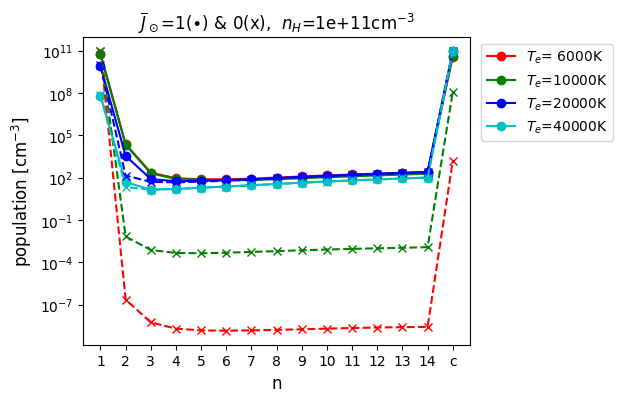

In [117]:
#----- level polulation in Statistical Eq. -----
Nh = 1.E11
Ne = 0.
Jfactor = 1.   # intensity of solar radiation
Tes = [6000, 10000, 20000, 40000]

n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = solspec(solar_spec,Jfactor=Jfactor)
tau = np.zeros(n_lev+1)
colors = ["r", "g", "b", "c", "m", "y", "k", "w"]
fig, ax = plt.subplots(1,1, figsize=(5,4), dpi=100)

j=0
for Te in Tes:
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Nh_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
    ax.plot(n,SE.n_SE*SE.Nh,'-o',label="$T_e$={0:5.0f}K".format(SE.Te), color=colors[j])
    j += 1

Jfactor = 0.
ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor
j=0
for Te in Tes:
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Nh_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
    ax.plot(n,SE.n_SE*SE.Nh,'--x'.format(SE.Te), color=colors[j])
    j += 1

ax.set_yscale("log")
ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel('population [cm$^{-3}$]', fontsize=12)
title = r"$\overline{J}_\odot$=1($\bullet$) & 0(x)"+",  $n_H$={0:5.0e}cm$^{{-3}}$".format(SE.Nh)
plt.title(title,fontsize=12)
ax.legend(bbox_to_anchor=(1.01,1),fontsize=10,ncol=1)

plt.show()

#### Dominant population         $\qquad n_1 + n_p >> \sum\limits_{2\le i\le n_{max}}n_i$

Transitions from $n=1$ and c control the population in excitation levels between them.

### relaxation time
$\frac{dn_i}{dt}=A_i - B_i n_i \quad \rightarrow \quad A_i = B_i n_i^0 \quad$
in statistical eq.
 
$n_i = n_i^0+\Delta n_i \quad 
\rightarrow \frac{dn_i}{dt}=\frac{d\Delta n_i}{dt} = A_i - B_i n_i = -B\Delta n_i
\quad \rightarrow \quad \Delta n_i \propto \exp(-B_i t)$

relaxation time, $\tau_i = 1/B_i = 1/\sum(R[:,i]+C[:,i])$




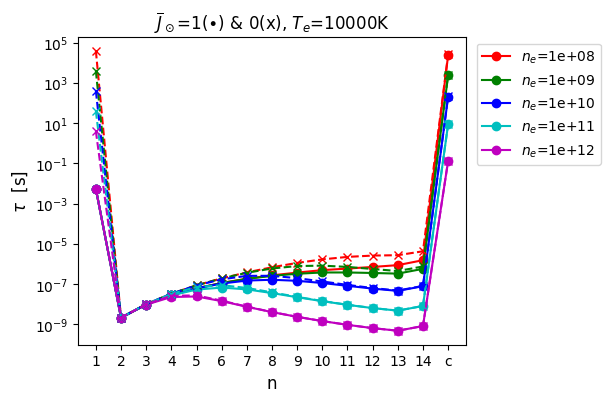

In [118]:
#--- relaxation time vs. n & Ne ----------------------------------------
Te = 10000.
Jfactor = 1.   # intensity of solar radiation
Nes = [1E8, 1E9, 1E10, 1E11, 1E12]

ssp = solspec(solar_spec,Jfactor=Jfactor)
tau = np.zeros(n_lev+1)
colors = ["r", "g", "b", "c", "m", "y", "k", "w"]
fig, ax = plt.subplots(1,1, figsize=(5,4), dpi=100)

j=0
for Ne in Nes:
    slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
    for i in range(n_lev+1):
        tau[i] = 1./(Rate.Rmat[:,i].sum()+Rate.Cmat[:,i].sum())
    ax.plot(n,tau,'-o',label="$n_e$={0:3.0e}".format(Ne), color=colors[j])
    j += 1

Jfactor = 0.
ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor
ssp.PI_intensity[:,:] *= Jfactor
j=0
for Ne in Nes:
    slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
    for i in range(n_lev+1):
        tau[i] = 1./(Rate.Rmat[:,i].sum()+Rate.Cmat[:,i].sum())
    ax.plot(n,tau,'--x',color=colors[j])
    j += 1

ax.set_yscale("log")
ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel(r"$\tau$  [s]", fontsize=12)
title = r"$\overline{J}_\odot$=1($\bullet$) & 0(x)"+", $T_e$={0:5.0f}K".format(Te)
plt.title(title,fontsize=12)
ax.legend(bbox_to_anchor=(1.01,1),fontsize=10,ncol=1)

plt.show()

### $\tau_1, \tau_c >> \tau_{2\sim N},$ 
=> level population for $n = 2 \sim N$ can be calculated under fixed $n_1$ and $n_p$

at $n_e=10^{10-11}cm^{-3}, \tau_c$ is in order of 10$$\sim$$100sec regardless of $J_\odot$

### Rate equation for level $1\sim N$ and $c$ (ion) 

#### 
$$
\frac{d}{dt} 
\begin{bmatrix}
n_1\\
n_2\\
\vdots \\
n_N\\
n_c
\end{bmatrix}
=
\begin{bmatrix}
\text{右辺の式など}
\end{bmatrix}
$$


### Statistical equiliblium for level $1\sim N$ and $c$ (ion)

#### 
$$
\frac{d}{dt}
\begin{bmatrix}
n_1\\
n_2\\
\vdots \\
n_N\\
n_c \\
\end{bmatrix}
=
\begin{bmatrix}
0\\
0\\
\vdots \\
0\\
0 \\
\end{bmatrix}
=
\begin{bmatrix}
T_{11} & T_{12}& \dots & T_{2c} & T_{1c}\\
T_{21} & T_{22} & & T_{2N} & T_{2c} \\
\vdots & & \ddots & & \vdots \\
T_{N1} & T_{N2} & & T_{NN} & T_{Nc}\\
T_{c1} & T_{c2} & \dots & T_{cN} & T_{cc}\\
\end{bmatrix}
\cdot
\begin{bmatrix}
n_1\\
n_2\\
\vdots \\
n_N\\
n_c \\
\end{bmatrix}
\qquad \rm{with} \sum n_i = 1
$$

### Solving SE with fixed $n_1 \, \& \, n_c$ 

#### 
$$
\frac{d}{dt}
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
=
\begin{bmatrix}
0\\
\vdots \\
0\\
\end{bmatrix}
=
n_1\begin{bmatrix}
T_{21}\\
\vdots \\
T_{N1}\\
\end{bmatrix}
+
n_c
\begin{bmatrix}
T_{2c}\\
\vdots \\
T_{Nc}\\
\end{bmatrix}
+
\begin{bmatrix}
T_{22} & & T_{2N}\\
 & \ddots &  \\
T_{N2} & & T_{NN}\\
\end{bmatrix}
\cdot
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
$$ 
すなわち、

$$
- n_1\begin{bmatrix}
T_{21}\\
\vdots \\
T_{N1}\\
\end{bmatrix}
-
n_c
\begin{bmatrix}
T_{2c}\\
\vdots \\
T_{Nc}\\
\end{bmatrix}
\equiv
\begin{bmatrix}
V_{2}\\
\vdots \\
V_{N}\\
\end{bmatrix}
=
\begin{bmatrix}
T_{22} & & T_{2N}\\
 & \ddots &  \\
T_{N2} & & T_{NN}\\
\end{bmatrix}
\cdot
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
\qquad $$ 
を逆行列で解く。



### Level population in ionization non-equiliblium

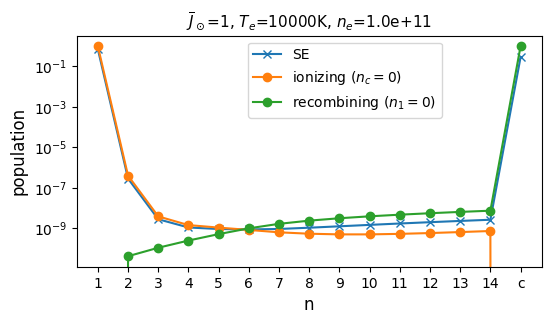

In [119]:
# calculate level population in Non Ionization Equil.
def calc_NIE(atom, slab, wMesh, solar_spec, n1, n_proton):
    ## use rate_only=True to acquire the transition matrix (R matrix and C matrix) without solving linear equation
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, solar_spec, None, rate_only=True)  #  level populations etc.
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rate.Rmat, Rate.Cmat)
    # print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    # print(f"Amat has shape: {A.shape}")
    b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    ## solve Ax=b
    nArr = np.linalg.solve(A, b) ## population density for levels n=2,3,...,N
    #print(f"nArr shape: {nArr.shape}")
    pop = np.zeros(len(nArr)+2)
    pop[0] = n1 ; pop[1:-1] = nArr ; pop[-1] = n_proton
    Nh = pop.sum()
    SE.n_SE = pop/Nh
    SE.Nh = Nh
    SE.Te = slab.Te
    SE.Ne = slab.Ne

    return(SE,Rate)

#----------------------------------------------------------------------
Te = 10000.
Ne = 1.E11
Jfactor = 1.   # intensity of solar radiation
#Nes = [1E8, 1E9, 1E10, 1E11, 1E12]

n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = solspec(solar_spec,Jfactor=Jfactor)
slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 

fig, ax = plt.subplots(1,1, figsize=(6,3), dpi=100)

SE0, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
ax.plot(n,SE0.n_SE,'-x', label='SE')#, color=colors[j])

n1 = 1.E10  ; n_proton = 0.E0  # cm-3,  ionizing plasma
SE1, Rate1 = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)
ax.plot(n,SE1.n_SE,'-o', label='ionizing ($n_c=0$)')#, color=colors[j])

n1 = 0.E0  ; n_proton = 1.E10  # cm-3,  recombining plasma
SE2, Rate2 = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)
ax.plot(n,SE2.n_SE,'-o', label='recombining ($n_1=0$)')#, color=colors[j])

ax.set_yscale("log")
ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel("population", fontsize=12)
title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K, $n_e$="+ \
    f"{Ne:3.1e}" #, $n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"

ax.legend(bbox_to_anchor=(0.8,1.0),fontsize=10,ncol=1)

plt.title(title,fontsize=11)

plt.show()

In [153]:
help_(slab)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atmosphere0D
|- Nh                      float                                v: 200000000000.0
|- Ne                      float                                v: 100000000000.0
|- Te                      float                                v: 10000.0
|- Vd                      float                                v: 0.0
|- Vt                      float                                v: 500000.0
|- Ti                      float                                v: -1.0
|- ndim                    int                                  v: 0
|- is_uniform              bool                                 v: True
|- Tr                      float                                v: 6000.0
|- use_Tr                  bool                     

### Line intensity:     $I=A_{ji}n_j h\nu$

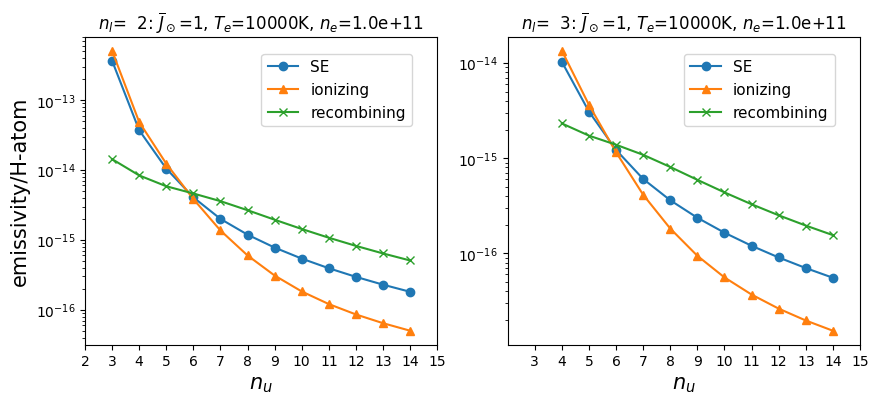

In [120]:
# Balmer and Paschen line intensities in SE and NIE

idxI = atom.Line['idxI']
fig, axs = plt.subplots(1,2, figsize=(10,4), dpi=100)
n_lev = np.size(atom.Level)-1
nmax = n_lev
depth = 1000000.

nls = [2,3]  # lower level n,  nl=2 for Balmer series

for k in range(2):
    nl = nls[k]
    jj = np.where(idxI == nl-1)
    Aji = atom.Line['AJI'][jj]
    idxJ = atom.Line['idxJ'][jj]
    eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]
    n_lev = np.size(atom.Level)-1
    n = np.arange(nl,n_lev+1,dtype='int')  # n-array for levels
    ax = axs[k]

    Nj0 = SE0.n_SE[idxJ]
    ax.plot(idxJ+1,Aji*Nj0*eps,'-o',label='SE')
    
    Nj1 = SE1.n_SE[idxJ]
    ax.plot(idxJ+1,Aji*Nj1*eps,'-^',label='ionizing')

    Nj2 = SE2.n_SE[idxJ]
    ax.plot(idxJ+1,Aji*Nj2*eps,'-x',label='recombining')

    ax.set_xlim(2,nmax+1)
    ax.set_xticks(np.arange(nl,nmax+2))
    ax.set_xlabel('$n_u$', fontsize=15)
    ax.set_yscale('log')
    #ax.set_ylim(1e-18,1e-12)
    #ax.set_ylabel('relative intensity / H-atom')
    if k == 0:
        ax.set_ylabel('emissivity/H-atom', fontsize=15)
    title = r"$n_l$="+f"{nl:3.0f}: "
    title = title+r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K, $n_e$="+ \
        f"{Ne:3.1e}"
    ax.set_title(title,fontsize=12)
    #plt.title(title,fontsize=13)

    ax.legend(bbox_to_anchor=(0.95,0.97),fontsize=11,ncol=1)

plt.show()


------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
CloudModel_Container
|- w0                      ndarray                              s: (91,)
|- tau_max                 ndarray                              s: (91,)
|- Ibar                    ndarray                              s: (91,)
|- Src                     ndarray                              s: (91,)
|- tau_1D                  ndarray                              s: (3731,)
|- prof_1D                 ndarray                              s: (3731,)
|- wl_1D                   ndarray                              s: (3731,)
|- Line_mesh_idxs          ndarray                              s: (91, 2)
|- line_emissivity         ndarray                              s: (91,)
|- line_absorption         ndarray                  

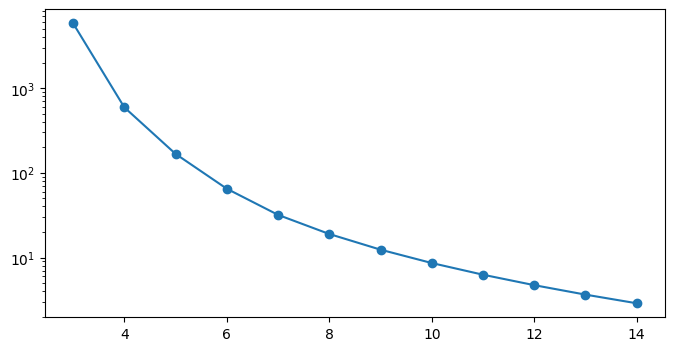

array([13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])

In [145]:
l = CloudModel.SE_to_slab_0D_(atom, slab, SE0, depth=depth)      # hydrogen lines intensity
help_(l)
idxI = atom.Line['idxI']
jj = np.where(idxI == 1)[0]  # Balmer series
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]

fig, ax = plt.subplots(1,1, figsize=(8,4), dpi=100)
ax.plot(idxJ+1,l.Ibar[jj],'-o',label='SE')
#ax.plot(l.Ibar[0:30],'-o',label='SE')
ax.set_yscale('log')
plt.show()
jj

In [ ]:
help_(atom)
nn13 = np.where((atom.Line['idxI'] == 1) & (atom.Line['idxJ'] == 13))
i1,i2 = l.Line_mesh_idxs[24,:]

nn13

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atom
|- Z                       int                                  v: 1
|- Mass                    float                                v: 1.008
|- Abun                    float                                v: 1.0
|- nLevel                  int                                  v: 15
|- nLine                   int                                  v: 91
|- nCont                   int                                  v: 14
|- nTran                   int                                  v: 105
|- nRL                     int                                  v: 0
|- Level                   struct array                         s: (15,)
  |-  erg                  float64                              s: (15,)
  |-  g                 

(array([24]),)

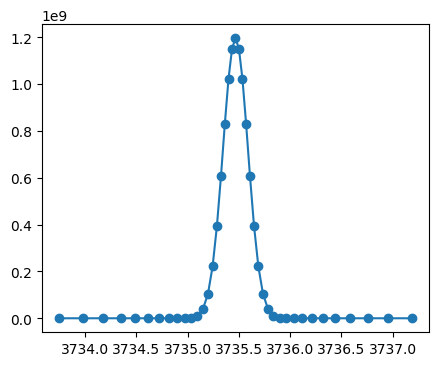

In [137]:
fig, ax = plt.subplots(1,1, figsize=(5,4), dpi=100)

#ax.plot(idxJ+1,l.Ibar[idxJ],'-o',label='SE')
i1,i2 = l.Line_mesh_idxs[23,:]
ax.plot(l.wl_1D[i1:i2]*1e8,l.prof_1D[i1:i2],'-o',label='SE')
plt.show()


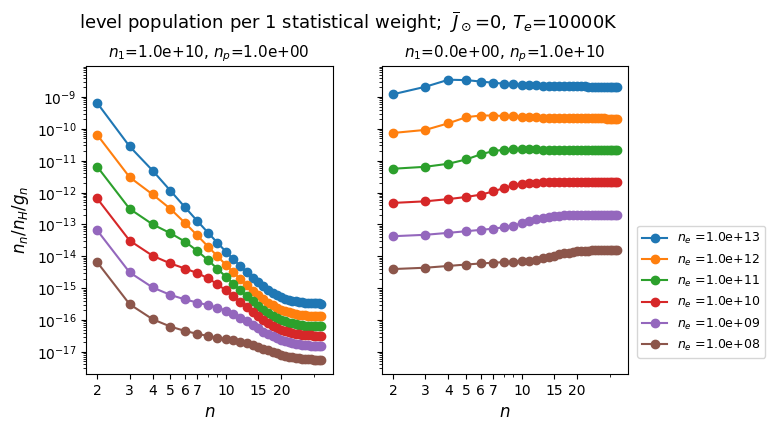

In [143]:
# population of n = 2 - N levels vs. Ne
import matplotlib.ticker as ticker

Te = 10000
Jfactor = 0.   # intensity of solar radiation
Nes = [1E8, 1E9, 1E10, 1E11, 1E12, 1E13]
perg = 1   # display population per statistical weight if perg=1, otherwise display population itself

Nes.reverse()
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion
ssp = solspec(solar_spec,Jfactor=Jfactor)

fig, axs = plt.subplots(1,2, figsize=(7,4), dpi=100, sharey=True)
if perg == 1:
    g = atom.Level['g']
    stitle = "level population per 1 statistical weight;  "
    ylabel = "$n_n/n_H/g_n$"
else:
    g = np.ones(n_lev+1)
    stitle = "level population;  "
    ylabel = "$n_n/n_H$"

n1 = 1.E10  ; n_proton = 1.E0  # cm-3,  ionizing plasma
ax = axs[0]
for Ne in Nes:
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)
    ax.plot(n[1:-1],SE.n_SE[1:-1]/g[1:-1],'-o', label=r"$n_e$ ="+f"{Ne:3.1e}")#, color=colors[j])

xticks = [2,3,4,5,6,7,10,15,20]
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
ax.set_xlabel('$n$', fontsize=12)
ax.set_yscale("log")
ax.set_ylabel(ylabel, fontsize=12)
#title = r"$\overline{J}_\odot$="+f"{Jbar:1.0f}, $T_e$=" +f"{Te:5.0f}K, "+ \
#    " $n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
title = r"$n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
ax.set_title(title,fontsize=11)

n1 = 0.E0  ; n_proton = 1.E10  # cm-3,  recombining plasma
ax = axs[1]
for Ne in Nes:
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)
    ax.plot(n[1:-1],SE.n_SE[1:-1]/g[1:-1],'-o', label=r"$n_e$ ="+f"{Ne:3.1e}")#, color=colors[j])

xticks = [2,3,4,5,6,7,10,15,20]
ax.set_xscale("log")
#ax.set_xlim([2,20])
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
#ax.set_xticklabels(str(xticks), fontsize=10)
ax.set_xlabel('$n$', fontsize=12)
ax.set_yscale("log")
title = r"$n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

stitle = stitle + r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K"
plt.suptitle(stitle, fontsize=13, y=1.02)

plt.show()

## Ionizing and recombining components
### Population coefficients   $r_1(n) \,  \& \,  r_c(n)$
from Fujimoto 2004

#### 
$$
\frac{d}{dt}
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
=n_1\begin{bmatrix}
T_{N1}\\
\vdots \\
T_{21}\\
\end{bmatrix}
+
n_c
\begin{bmatrix}
T_{Nc}\\
\vdots \\
T_{2c}\\
\end{bmatrix}
+
\begin{bmatrix}
T_{22} & & T_{2N}\\
 & \ddots &  \\
T_{N2} & & T_{NN}\\
\end{bmatrix}
\cdot
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
=\begin{bmatrix}
0\\
\vdots \\
0\\
\end{bmatrix}
$$ 
#### in LTE    $\quad n_i = \frac{Z_i}{Z_1} 𝑛_1 = Z_i n_e n_c$  
$\quad Z_i = \frac{g_i}{2U_{I+1}}  \left(\frac{h^2}{2
\pi m_e k_B T}\right)^{3/2} e^{\chi_i/kT}, \quad g_i= 2 i^2, \quad  U_{I+1}=1 
\quad \chi_i = \frac{R_y}{i^2}$
#### $ n_i = 𝑟_1(i) \frac{Z_i}{Z_1} 𝑛_1 + 𝑟_c(i)Z_i n_e n_c, \quad i=2\sim N $
とおく　 ionizing & recombining components
<img src="attachment:image-13.png" width="700" align="left">
####  
$𝑛_1, 𝑛_𝑐$ が変化したとき、$𝑛_{2\sim𝑁}$ （すなわち$𝑟_1(𝑖). 𝑟_c(𝑖)$）は
即座に応答。$𝑛_1, 𝑛_𝑐$について２つの独立した等式とみる。
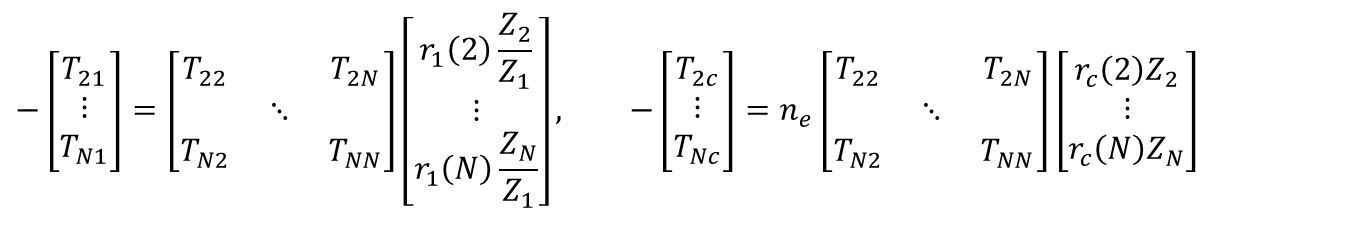
それぞれ𝑛_𝑐=0, 𝑛_1=0 とおいたことと等しい。


r1,rc have shape: (32, 50)


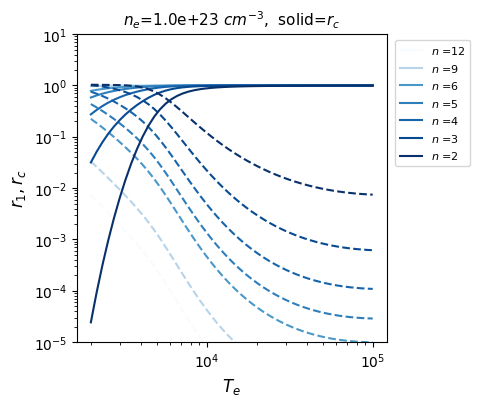

In [165]:
#--------- Boltzmann-Saha coeff. -----------------------
def BoltSahaZ(Te,n):
    Z = n**2 *(Cst.h_**2/2./np.pi/Cst.me_/Cst.k_/Te)**(1.5)*np.exp(Cst.E_Rydberg_/n**2/Cst.k_/Te)
    return(Z)

#--------------------------------------------------------

Jfactor = 0.   # intensity of solar radiation
Ne = 1E23 # <== very high density!
nTe = 50
Tes = np.logspace(3.3, 5, nTe)
n_lev = np.size(atom.Level)-1

ssp = solspec(solar_spec,Jfactor=Jfactor)
r1 = np.zeros([n_lev-1,nTe])
rc = np.zeros([n_lev-1,nTe])
print(f"r1,rc have shape: {r1.shape}")
ns = np.arange(2,n_lev+1,dtype='int')

for j in range(0,nTe):
#for j in range(0,20):
    Te = Tes[j]
    Zs = BoltSahaZ(Te,ns)
    UI = LTELib.Ufunc_('H_I',Te)
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
    Rmat = Rate.Rmat
    Cmat = Rate.Cmat
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)
    #print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    #print(f"Amat has shape: {A.shape}")  #b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    b1 = -Pmat[1:-1,0]
    v1 = np.linalg.solve(A, b1) ## solve Ax=b, for levels n=2,3,...,N
    r1[:,j] = v1*BoltSahaZ(Te,1)/Zs
    #print(BoltSahaZ(Te,1)/Zs[0:3])
    bc = -Pmat[1:-1,-1]
    vc = np.linalg.solve(A, bc) ## solve Ax=b, for levels n=2,3,...,N
    rc[:,j] = vc/Ne/Zs
    
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=100)

cmap = plt.get_cmap('Blues')
nn = [0,1,2,3,4,7,10]#,14,18]
#nn = [0,1,2,3]
nn.reverse()
#for i in range(0,n_lev-1):
for i in nn:
    ind = (np.max(nn)-i)/np.max(nn)
    ax.plot(Tes,rc[i,:],label=r"$n$ ="+f"{ns[i]:1d}",color=cmap(ind))
    ax.plot(Tes,r1[i,:],'--',color=cmap(ind))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim([1e-5,10])
ax.set_xlabel('$T_e$', fontsize=12)
ax.set_ylabel('$r_1, r_c$', fontsize=12)

title = r"$n_e$="+f"{Ne:3.1e}"+r" $cm^{-3}$"+ ",  solid=$r_c$"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,1.),fontsize=8,ncol=1)

# np.set_printoptions(precision=2, suppress=False)
# Pmat

### ionizing and recombining populations
### $ \frac{n_I(i)}{n_1} = 𝑟_1(i) \frac{Z_i}{Z_1}, \quad  \frac{n_R(i)}{n_c} = 𝑟_c(i)Z_i n_e, \quad i=2\sim N $


nI,nR have shape: (13, 50)


Text(0.5, 0.98, '$T_e$=1.0e+04 $K$,  Red w/ radiation')

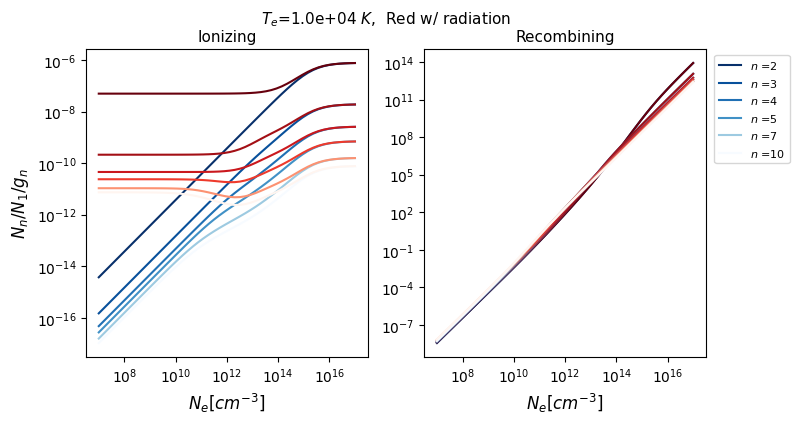

In [116]:
#  n(i) vs. Ne
nNe = 50
Nes = np.logspace(7,17,nNe)
Jfactor = 1.   # intensity of solar radiation
Te = 1.28e5   
Te = 1.e4   

n_lev = np.size(atom.Level)-1

ssp0 = solspec(solar_spec,Jfactor=0)
ssp1 = solspec(solar_spec,Jfactor=1)

nI0 = np.zeros([n_lev-1,nNe]) # ionizing, no solar irradience
nI1 = np.zeros([n_lev-1,nNe]) # ionizing, with solar irradience
nR0 = np.zeros([n_lev-1,nNe]) # recombining, no solar irradience
nR1 = np.zeros([n_lev-1,nNe])
print(f"nI,nR have shape: {r1.shape}")
ns = np.arange(2,n_lev+1,dtype='int')
gs = 2*ns**2

Zs = BoltSahaZ(Te,ns)
UI = LTELib.Ufunc_('H_I',Te)
for j in range(0,nNe):
#for j in range(0,1):
    Ne = Nes[j]
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp1, None, rate_only=True)  #  level populations etc.
    Rmat = Rate.Rmat
    Cmat = Rate.Cmat
    Cmat = ch.Cmat_HI_Theoretical(atom.nLevel,Te,Ne)
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)
    #print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    #print(f"Amat has shape: {A.shape}")  #b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    b1 = -Pmat[1:-1,0]
    v1 = np.linalg.solve(A, b1) ## solve Ax=b, for levels n=2,3,...,N
    nI1[:,j] = v1  
    #print(BoltSahaZ(Te,1)/Zs[0:3])
    bc = -Pmat[1:-1,-1]
    vc = np.linalg.solve(A, bc) ## solve Ax=b, for levels n=2,3,...,N
    nR1[:,j] = vc*Ne

    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp0, None, rate_only=True)  #  level populations etc.
    Rmat = Rate.Rmat
    Cmat = Rate.Cmat
    Cmat = ch.Cmat_HI_Theoretical(atom.nLevel,Te,Ne)
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    b1 = -Pmat[1:-1,0]
    v1 = np.linalg.solve(A, b1) ## solve Ax=b, for levels n=2,3,...,N
    nI0[:,j] = v1  
    bc = -Pmat[1:-1,-1]
    vc = np.linalg.solve(A, bc) ## solve Ax=b, for levels n=2,3,...,N
    nR0[:,j] = vc*Ne
    
    
fig, axs = plt.subplots(1,2, figsize=(8,4), dpi=100)

cmap = plt.get_cmap('Blues')
cmapr = plt.get_cmap('Reds')
nn = [0,1,2,3,5,8]#,13,18]
ax = axs[0]
##nn.reverse()
#for i in range(0,n_lev-1):
for i in nn:
    ind = (np.max(nn)-i)/np.max(nn)
    ax.plot(Nes,nI0[i,:]/gs[i],label=r"$n$ ="+f"{ns[i]:1d}",color=cmap(ind))
    ax.plot(Nes,nI1[i,:]/gs[i],color=cmapr(ind))  # red w/ radiation
    #ax.plot(Nes,nR[i,:]/gs[i],'--',color=cmapr(ind))

ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim([1e-5,10])
ax.set_xlabel(r'$N_e [cm^{-3}]$', fontsize=12)
ax.set_ylabel('$N_n/N_1/g_n$', fontsize=12)

ax.set_title("Ionizing",fontsize=11)

ax = axs[1]
for i in nn:
    ind = (np.max(nn)-i)/np.max(nn)
    ax.plot(Nes,nR0[i,:]/gs[i],label=r"$n$ ="+f"{ns[i]:1d}",color=cmap(ind))
    ax.plot(Nes,nR1[i,:]/gs[i],color=cmapr(ind))
    #ax.plot(Nes,nR[i,:]/gs[i],'--',color=cmapr(ind))

ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim([1e-5,10])
ax.set_xlabel(r'$N_e [cm^{-3}]$', fontsize=12)

ax.set_title("Recombining",fontsize=11)

ax.legend(bbox_to_anchor=(1.01,1.),fontsize=8,ncol=1)

#title = r"$T_e$="+f"{Te:3.1e}"+r" $K$"+r",  $J$="+f"{Jfactor:1.0f}"
title = r"$T_e$="+f"{Te:3.1e}"+r" $K$,  Red w/ radiation"
plt.suptitle(title,fontsize=11)

#ax.plot([1e6,1e12],[1e-10,1e-4],'--')


## line intensity

In [90]:
ssp.PI_intensity[0,:]
help_(l)


------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
CloudModel_Container
|- w0                      ndarray                              s: (171,)
|- tau_max                 ndarray                              s: (171,)
|- Ibar                    ndarray                              s: (171,)
|- Src                     ndarray                              s: (171,)
|- tau_1D                  ndarray                              s: (7011,)
|- prof_1D                 ndarray                              s: (7011,)
|- wl_1D                   ndarray                              s: (7011,)
|- Line_mesh_idxs          ndarray                              s: (171, 2)
|- line_emissivity         ndarray                              s: (171,)
|- line_absorption         ndarray            

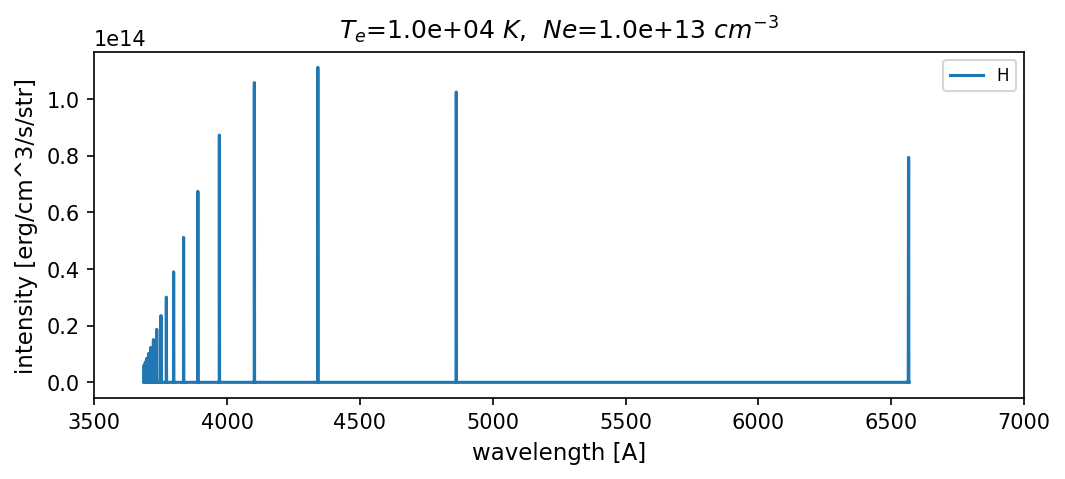

In [ ]:
#----- line intensity -----
Te = 10000.
Ne = 1e13
Jfactor = 1.   # intensity of solar radiation
depth = 1000000.

#-----  setup  -----
atom, wMesh, path_dict = Atom.init_theoretical_hydrogen_atom_(nLevel=20)
slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
solar_spec  = Radiation.init_Radiation_(slab, wMesh)
ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor 
wls = ssp.backRad[0,:]*1E8     # wl in A"
wls_air = BasicP.vacuum_to_air_(wls,'AA')   # wavelength in air of background solar spectrum [A]
Isolar = ssp.backRad[1,:].copy()   # background solar spectrum intensity    "    [erg/cm^3/s/str]

SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
l = CloudModel.SE_to_slab_0D_(atom, slab, SE, depth=depth)      # hydrogen lines intensity

fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)

wrange = [3500, 7000]  # visible range in Angstrom

# Filter data to visible range to fix y-axis scaling
wl_ang = l.wl_1D * 1e8   # wavelength in Angstrom
ii = (wl_ang >= wrange[0]) & (wl_ang <= wrange[1])
ax.plot(wl_ang[ii], l.prof_1D[ii], label='H')

#ax.set_xscale("log")
ax.set_xlim(wrange[0], wrange[1])
#ax.set_yscale("log")
#ax.set_ylim(1E7,1E14)
ax.set_xlabel("wavelength [A]", fontsize=11)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=11)
title = r"$T_e$="+f"{Te:3.1e}"+r" $K$,  $Ne$="+f"{Ne:3.1e}"+r" $cm^{-3}$"
plt.title(title,fontsize=12)
ax.legend(fontsize=8,ncol=1)
plt.show()

In [51]:
# Data diagnostics - check what's in l.prof_1D
print("=== Line Profile Data Check ===")
print(f"l.prof_1D min: {l.prof_1D.min()}")
print(f"l.prof_1D max: {l.prof_1D.max()}")
print(f"l.prof_1D mean: {l.prof_1D.mean()}")
print(f"l.prof_1D non-zero count: {(l.prof_1D != 0).sum()} / {len(l.prof_1D)}")
print(f"\nSolar spectrum intensity (Isolar):")
print(f"Isolar min: {Isolar.min()}")
print(f"Isolar max: {Isolar.max()}")
print(f"Isolar mean: {Isolar.mean()}")
print(f"\nBackground radiation intensity (ssp.backRad[1,:]):")
print(f"ssp.backRad[1,:] min: {ssp.backRad[1,:].min()}")
print(f"ssp.backRad[1,:] max: {ssp.backRad[1,:].max()}")
print(f"ssp.backRad[1,:] mean: {ssp.backRad[1,:].mean()}")

=== Line Profile Data Check ===
l.prof_1D min: 0.0
l.prof_1D max: 8847768100641.885
l.prof_1D mean: 22037775921.72968
l.prof_1D non-zero count: 5083 / 7011

Solar spectrum intensity (Isolar):
Isolar min: nan
Isolar max: nan
Isolar mean: nan

Background radiation intensity (ssp.backRad[1,:]):
ssp.backRad[1,:] min: nan
ssp.backRad[1,:] max: nan
ssp.backRad[1,:] mean: nan


In [52]:
# Check wavelength mesh data
print("\n=== Wavelength Mesh Check ===")
wl_1D_angstrom = l.wl_1D * 1e8
print(f"l.wl_1D min (Angstrom): {wl_1D_angstrom.min()}")
print(f"l.wl_1D max (Angstrom): {wl_1D_angstrom.max()}")
print(f"l.wl_1D NaN count: {np.isnan(l.wl_1D).sum()}")
print(f"l.prof_1D NaN count: {np.isnan(l.prof_1D).sum()}")

# Check which data points are in the plotting range (3500-7000 A)
mask = (wl_1D_angstrom >= 3500) & (wl_1D_angstrom <= 7000)
print(f"\nData points in xlim range (3500-7000 A): {mask.sum()}")
if mask.sum() > 0:
    print(f"prof_1D values in range: min={l.prof_1D[mask].min()}, max={l.prof_1D[mask].max()}, mean={l.prof_1D[mask].mean()}")

# Show first 10 and last 10 wavelength/intensity pairs
print(f"\nFirst 10 wavelengths (A):", wl_1D_angstrom[:10])
print(f"First 10 intensities (erg/cm^3/s/str):", l.prof_1D[:10])
print(f"\nLast 10 wavelengths (A):", wl_1D_angstrom[-10:])
print(f"Last 10 intensities (erg/cm^3/s/str):", l.prof_1D[-10:])


=== Wavelength Mesh Check ===
l.wl_1D min (Angstrom): 913.8658014396758
l.wl_1D max (Angstrom): 2883337.650039738
l.wl_1D NaN count: 0
l.prof_1D NaN count: 0

Data points in xlim range (3500-7000 A): 697
prof_1D values in range: min=0.0, max=13968231501.813202, mean=214897447.76093382

First 10 wavelengths (A): [1215.10814428 1215.1838531  1215.24809907 1215.30285094 1215.34973935
 1215.39011487 1215.42509608 1215.45560949 1215.48242244 1215.50617049]
First 10 intensities (erg/cm^3/s/str): [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 3.49895113e+00 7.57899631e+03 2.53070516e+06 2.12215279e+08
 6.35695285e+09 8.75370353e+10]

Last 10 wavelengths (A): [2882394.03935085 2882450.33944881 2882513.90557465 2882586.24446852
 2882669.17531996 2882764.89455983 2882876.05408797 2883005.85572288
 2883158.16523706 2883337.65003974]
Last 10 intensities (erg/cm^3/s/str): [2.58014024e-03 1.86508764e-04 6.22409463e-06 7.42264688e-08
 2.22531052e-10 0.00000000e+00 0.00000000e+00 0.000


=== Visible Range (3500-7000 A) Analysis ===
Number of points: 697
Wavelength range in visible: 3686.22 - 6567.72 A
Intensity range: 0.00e+00 - 1.40e+10 erg/cm^3/s/str

Intensity stats in visible range:
  Min: 0.0
  Max: 13968231501.813202
  Mean: 214897447.76093382
  Median: 71649.63887103842
  Zero values: 194


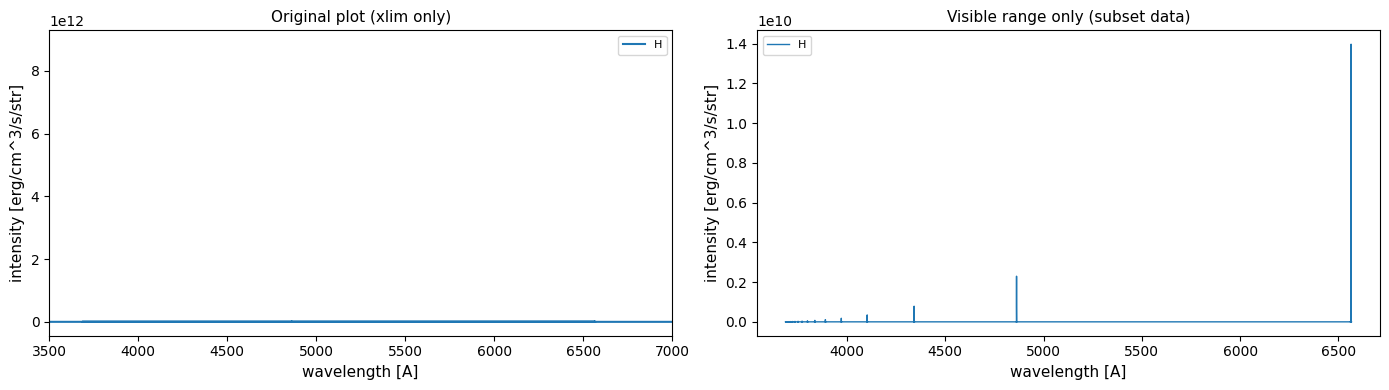


✓ Recommended fix: Plot only the data in the visible range instead of the entire array


In [53]:
# Find data points exactly in the visible range (3500-7000 A)
mask_vis = (wl_1D_angstrom >= 3500) & (wl_1D_angstrom <= 7000)
vis_wl = wl_1D_angstrom[mask_vis]
vis_prof = l.prof_1D[mask_vis]

print(f"\n=== Visible Range (3500-7000 A) Analysis ===")
print(f"Number of points: {len(vis_wl)}")
print(f"Wavelength range in visible: {vis_wl.min():.2f} - {vis_wl.max():.2f} A")
print(f"Intensity range: {vis_prof.min():.2e} - {vis_prof.max():.2e} erg/cm^3/s/str")
print(f"\nIntensity stats in visible range:")
print(f"  Min: {vis_prof.min()}")
print(f"  Max: {vis_prof.max()}")
print(f"  Mean: {vis_prof.mean()}")
print(f"  Median: {np.median(vis_prof)}")
print(f"  Zero values: {(vis_prof == 0).sum()}")

# Try plotting just the visible range
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), dpi=100)

# Left: Original plot method
ax1.plot(wl_1D_angstrom, l.prof_1D, label='H')
ax1.set_xlim(3500, 7000)
ax1.set_xlabel("wavelength [A]", fontsize=11)
ax1.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=11)
ax1.set_title("Original plot (xlim only)", fontsize=11)
ax1.legend(fontsize=8)

# Right: Plot only the visible range data (better approach)
ax2.plot(vis_wl, vis_prof, label='H', linewidth=1)
ax2.set_xlabel("wavelength [A]", fontsize=11)
ax2.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=11)
ax2.set_title("Visible range only (subset data)", fontsize=11)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Recommended fix: Plot only the data in the visible range instead of the entire array")

-------------------------------------------------------------------------------
## examine cmat[]  -- redundant

nI,nR have shape: (13, 50)


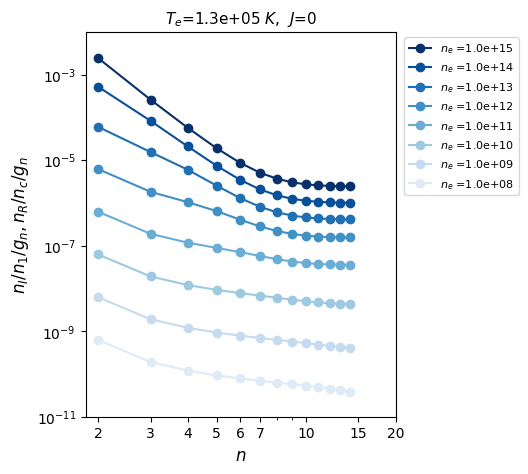

In [118]:
import matplotlib.ticker as ticker
#  n(i) vs. i 
lNe = [8,9,10,11,12,13,14,15]
lNe.reverse()
Nes = 10.**np.array(lNe)
nNe = len(Nes)
Jfactor = 0.   # intensity of solar radiation
Te = 1.28e5   
#Te = 1.e4   
##  Johnson(1972)'s Cmat is correct up to n~10

ssp = solspec(solar_spec,Jfactor=Jfactor)

nI = np.zeros([n_lev-1,nNe])
nR = np.zeros([n_lev-1,nNe])
print(f"nI,nR have shape: {r1.shape}")

fig, ax = plt.subplots(1,1, figsize=(4,5), dpi=100)

cmap = plt.get_cmap('Blues')
cmapr = plt.get_cmap('Reds')

for j in range(0,nNe):
    Ne = Nes[j]
    ind = (nNe-j)/nNe
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
    Rmat = Rate.Rmat
    Cmat = Rate.Cmat
    Cmat = ch.Cmat_HI_Theoretical(atom.nLevel,Te,Ne)
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)
    #print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    #print(f"Amat has shape: {A.shape}")  #b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    b1 = -Pmat[1:-1,0]
    v1 = np.linalg.solve(A, b1) ## solve Ax=b, for levels n=2,3,...,N
    nI[:,j] = v1
    ax.plot(ns,nI[:,j]/gs,'-o', label=r"$n_e$ ="+f"{Ne:3.1e}",color=cmap(ind))
    #print(BoltSahaZ(Te,1)/Zs[0:3])
    bc = -Pmat[1:-1,-1]
    vc = np.linalg.solve(A, bc) ## solve Ax=b, for levels n=2,3,...,N
    nR[:,j] = vc*Ne
    #ax.plot(ns,nR[:,j]/gs,'-x',color=cmapr(ind))

#ax.plot(ns,0.06*1./ns**6,'--')
xticks = [2,3,4,5,6,7,10,15,20]
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
#ax.set_xticklabels(str(xticks), fontsize=10)
ax.set_xlabel('$n$', fontsize=12)
ax.set_xlim([0,20])
ax.set_yscale("log")
ax.set_ylim([1e-11,1e-2])
ax.set_ylabel('$n_I/n_1/g_n, n_R/n_c/g_n$', fontsize=12)

title = r"$T_e$="+f"{Te:3.1e}"+r" $K$"+r",  $J$="+f"{Jfactor:1.0f}"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,1.),fontsize=8,ncol=1)


In [119]:
Cmat.shape

(15, 15)

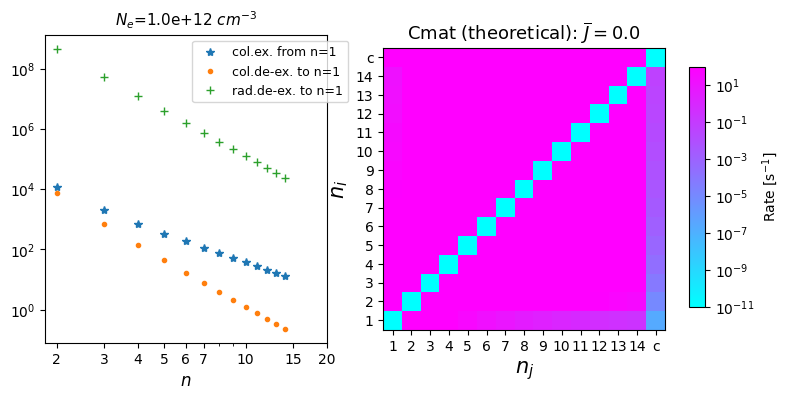

In [120]:
Ne = 1e12
slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
Rmat = Rate.Rmat
Cmat = Rate.Cmat
Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)

fig, axs = plt.subplots(1,2,figsize=[8,4])

ax=axs[0]
ax.plot(ns,Cmat[1:-1,0],'*',label='col.ex. from n=1')
ax.plot(ns,Cmat[0,1:-1],'.',label='col.de-ex. to n=1')
ax.plot(ns,Rmat[0,1:-1],'+',label=('rad.de-ex. to n=1'))
#ax.plot(ns,Pmat[1:-1,0],'--',label='ex. from n=1')
#ax.plot(ns,Pmat[0,1:-1],'--',label='de-ex. to n=1')
#ax.plot(A[:,0],'.')
ax.set_xscale('log')
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
ax.set_xlabel('$n$', fontsize=12)
ax.set_yscale('log')
title = r"$N_e$="+f"{Ne:3.1e}"+r" $cm^{-3}$"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(0.5,1.),fontsize=9,ncol=1)

title='Cmat (theoretical): '+r"$\overline{J}=$"+f"{Jfactor:3.1F}"
heatmap(axs[1], Cmat, title=title,vmin=vmin,vmax=vmax, colbar='Rate [s$^{-1}$]', last='c')



<function matplotlib.pyplot.show(close=None, block=None)>

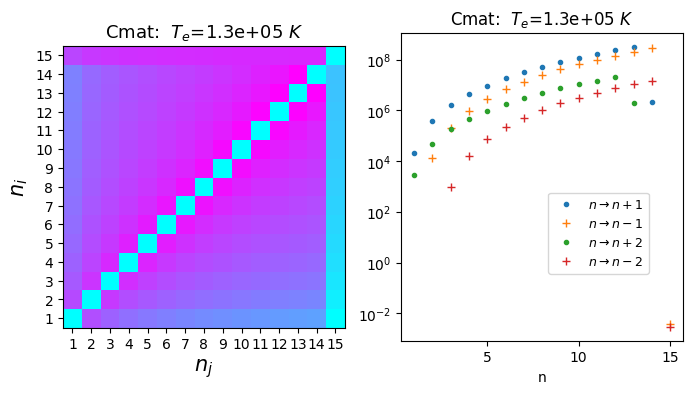

In [121]:
# Collisional excitation rate (Fujimoto 2004)
Te = 1.28e5
#Te = 1e4
nLev = atom.nLevel
Cmat = ch.Cmat_HI_Theoretical(nLev,Te,Ne)
nn = np.linspace(1,nLev,nLev,dtype=int)


fig, axs = plt.subplots(1,2,figsize=(8,4),dpi=100)
title = 'Cmat:  '+r"$T_e$="+f"{Te:3.1e}"+r" $K$"
heatmap(axs[0], Cmat,title=title)#, colbar='Rate [s$^{-1}$]') #,vmin=1e1, vmax=1e9)

ax = axs[1]
nn2 = nn[0:-1] ; ax.plot(nn2,Cmat[nn2,nn2-1],'.',label=r'$n \rightarrow n+1$')
nn2 = nn[1:]   ; ax.plot(nn2,Cmat[nn2-1-1,nn2-1],'+',label=r'$n \rightarrow n-1$')
nn2 = nn[0:-2] ; ax.plot(nn2,Cmat[nn2-1+2,nn2-1],'.',label=r'$n \rightarrow n+2$')
nn2 = nn[2:]   ; ax.plot(nn2,Cmat[nn2-1-2,nn2-1],'+',label=r'$n \rightarrow n-2$')
ax.set_yscale('log')
ax.set_xlabel('n')
ax.set_title(title)

ax.legend(bbox_to_anchor=(0.9,0.5),fontsize=9,ncol=1)


plt.show


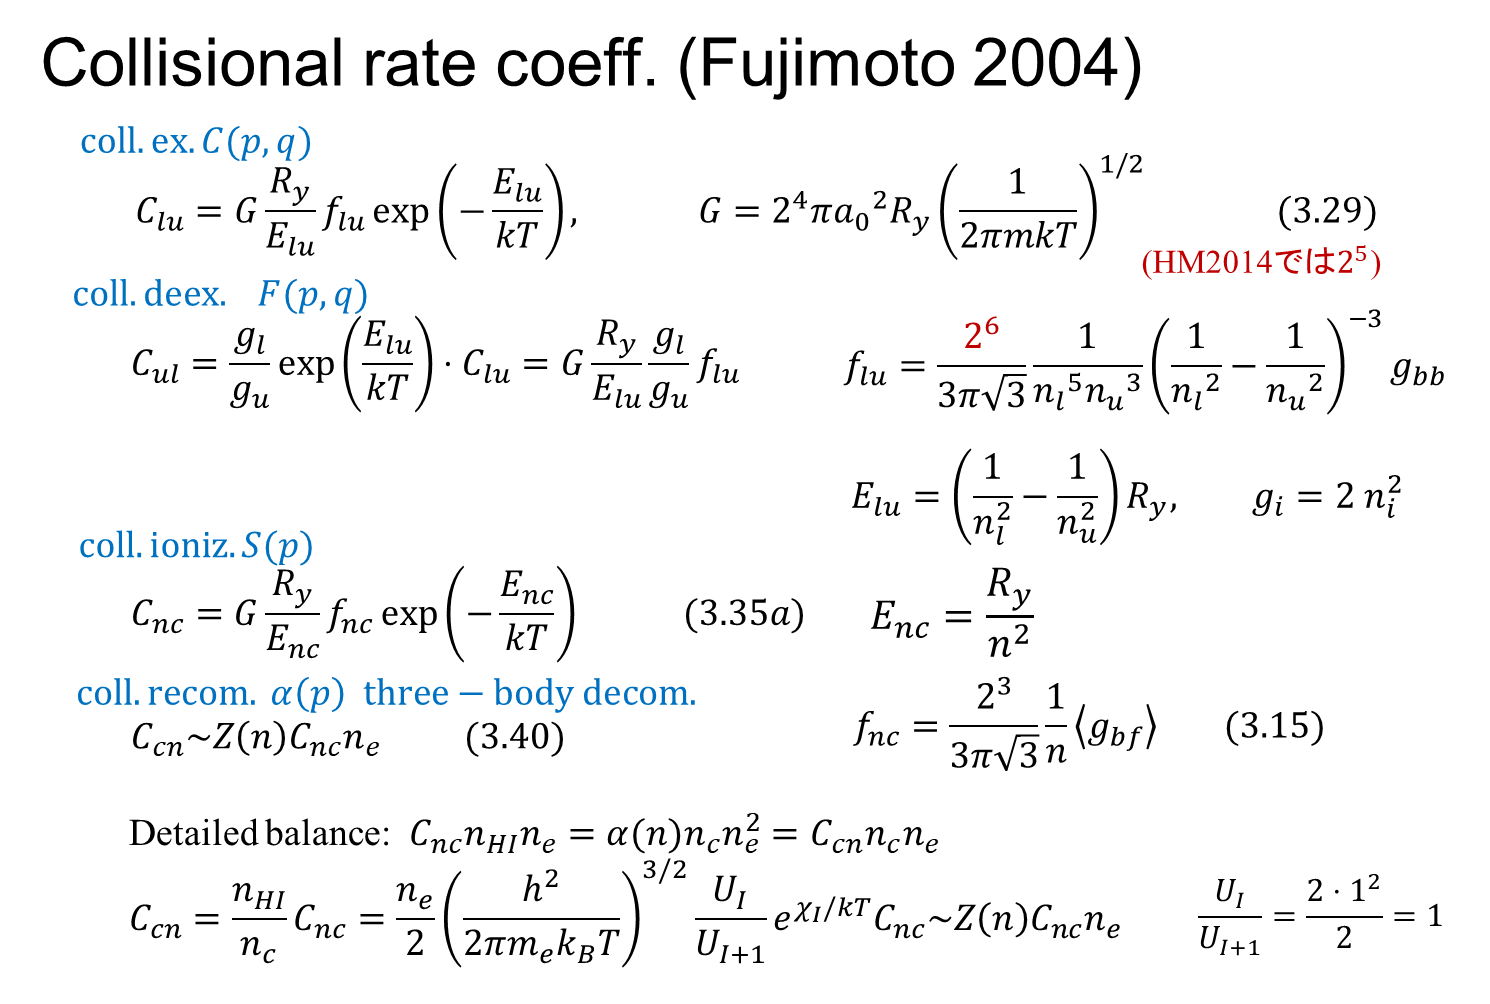

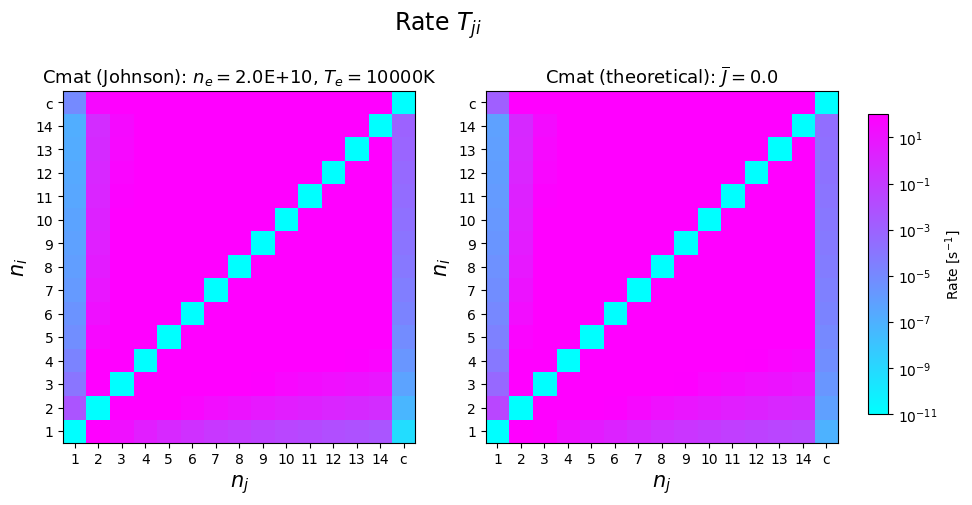

In [122]:
#  Cmat from theoretical foemula in Fujimoto 2004

Ne = 2.e10
Te = 1e4

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
Rmat = Rate.Rmat
Cmat = Rate.Cmat
Cmat2 = ch.Cmat_HI_Theoretical(atom.nLevel,Te,Ne)

fig, axs = plt.subplots(1,2, figsize=(10,5), dpi=100)#, sharey=True)
title='Cmat (Johnson): '+r"$n_e=$"+f"{SE.Ne:5.1E}, "+r"$T_e=$"+f"{SE.Te:5.0f}K"
heatmap(axs[0], Cmat, title=title,vmin=vmin,vmax=vmax, last='c')
title='Cmat (theoretical): '+r"$\overline{J}=$"+f"{Jfactor:3.1F}"
heatmap(axs[1], Cmat2, title=title,vmin=vmin,vmax=vmax, colbar='Rate [s$^{-1}$]', last='c')
plt.suptitle("Rate $T_{ji}$", fontsize=17, y=1.01)

plt.show()


C:\Users\ichim\AppData\Local\Temp\ipykernel_17260\2312568933.py:4: RuntimeWarning: invalid value encountered in divide
  heatmap(ax, Cmat2/Cmat, title='Cmat(theor.)/Cmat(Johnson)', vmin=0.1, vmax=2, colbar='Rate [s$^{-1}$]', last='c')


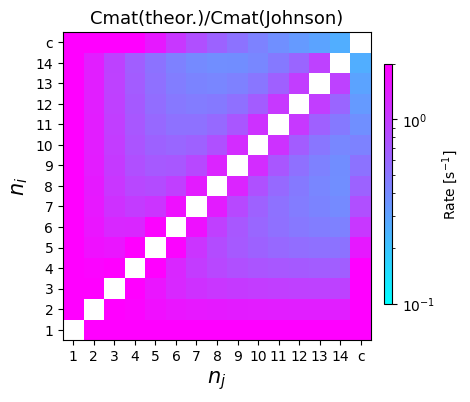

In [123]:
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=100)

title='Cmat (Johnson): '+r"$n_e=$"+f"{SE.Ne:5.1E}, "+r"$T_e=$"+f"{SE.Te:5.0f}K"
heatmap(ax, Cmat2/Cmat, title='Cmat(theor.)/Cmat(Johnson)', vmin=0.1, vmax=2, colbar='Rate [s$^{-1}$]', last='c')

i=10
#ax.plot(Cmat[i,:],'.',label='Johnson')
#ax.plot(Cmat2[i,:],'*',label='Theoretical')
#ax.set_yscale('log')
#ax.legend(bbox_to_anchor=(1.01,1),fontsize=10,ncol=1)

plt.show()

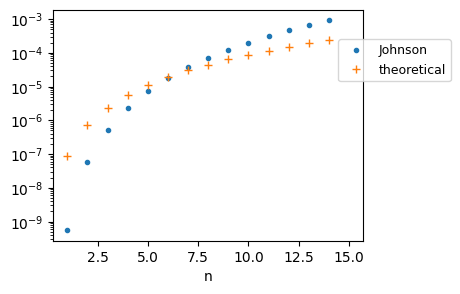

In [124]:
n = 5

fig, ax = plt.subplots(1,1,figsize=[4,3])
j = -1

ax.plot(nn,Cmat[:,j],'.',label='Johnson')
ax.plot(nn,Cmat2[:,j],'+',label='theoretical')
#ax.plot([n,n],[0,4e-5],'--')
ax.set_yscale('log')
ax.set_xlabel('n')
ax.legend(bbox_to_anchor=(0.9,0.9),fontsize=9,ncol=1)

plt.show()

In [125]:
nn

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

#

c:\Users\ichim\.conda\envs\spectra.py3.11\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


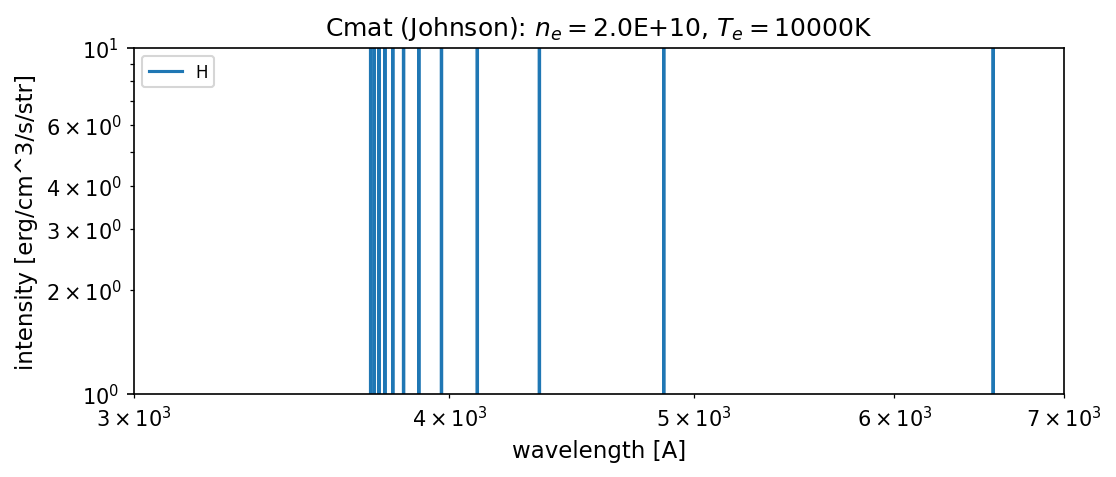

In [126]:
l = CloudModel.SE_to_slab_0D_(atom, slab, SE2, depth=depth)      # hydrogen lines intensity

fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(l.wl_1D*1e8,l.prof_1D,label='H')
ax.set_xscale("log")
#ax.set_xlim(0, 20000)
ax.set_xlim(3000, 7000)
ax.set_yscale("log")
#ax.set_ylim(1E7,1E12)
ax.set_xlabel("wavelength [A]", fontsize=11)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=11)
plt.title(title,fontsize=12)
ax.legend(fontsize=8,ncol=1)
plt.show()

## Line intensity

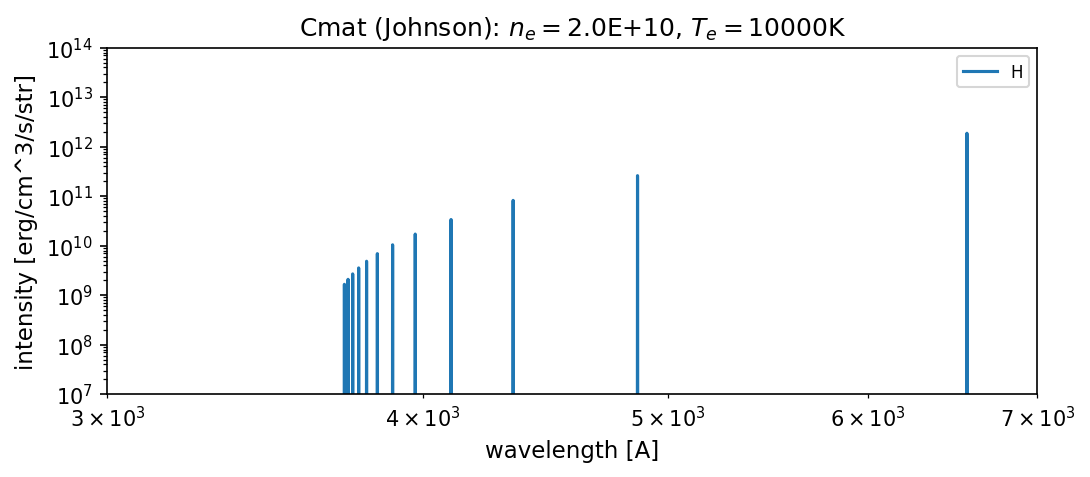

In [349]:
a = np.array([[1,2],[3,4]])
b = np.array([2,3]).reshape(-1,1)
print(a)
print(b)
print(a*b)

[[1 2]
 [3 4]]
[[2]
 [3]]
[[ 2  4]
 [ 9 12]]


In [ ]:
flux  cm^-3 s^-1
rate s^-1  -> relaxsation time


In [47]:
#np.set_printoptions(precision=3,floatmode="fixed",suppress="False") 
np.set_printoptions(precision=10,suppress="False") 
#np.log(Rate.Cmat *SE.n_SE.reshape(1,-1))
Rate.Cmat *SE.n_SE.reshape(1,-1)

array([[0.0000000000, 0.0000229197, 0.0000000187, 0.0000000015,
        0.0000000004, 0.0000000001, 0.0000000001, 0.0000000000,
        0.0000000004],
       [0.0016765116, 0.0000000000, 0.0000066270, 0.0000002959,
        0.0000000611, 0.0000000202, 0.0000000087, 0.0000000049,
        0.0000000371],
       [0.0000359081, 0.0001740715, 0.0000000000, 0.0000131762,
        0.0000014675, 0.0000003786, 0.0000001442, 0.0000000749,
        0.0000003428],
       [0.0000061110, 0.0000164469, 0.0000278792, 0.0000000000,
        0.0000392938, 0.0000051024, 0.0000014803, 0.0000006663,
        0.0000015580],
       [0.0000020592, 0.0000044093, 0.0000040293, 0.0000509896,
        0.0000000000, 0.0001047670, 0.0000143802, 0.0000048303,
        0.0000048367],
       [0.0000009499, 0.0000018137, 0.0000012948, 0.0000082469,
        0.0001304918, 0.0000000000, 0.0002511220, 0.0000380699,
        0.0000118825],
       [0.0000005218, 0.0000009325, 0.0000005858, 0.0000028420,
        0.0000212763, 0.000298

In [33]:
np.set_printoptions(precision=1,floatmode="fixed",suppress="False") 
SE.n_SE.reshape(1,-1)
np.log(Rate.Cmat)

C:\Users\ichim\AppData\Local\Temp\ipykernel_12680\2233984242.py:3: RuntimeWarning: divide by zero encountered in log
  np.log(Rate.Cmat)


array([[ -inf,   5.1,   2.7,   1.1,  -0.1,  -1.0,  -1.8,  -2.5, -21.3],
       [ -5.3,  -inf,   8.5,   6.4,   5.0,   3.9,   3.0,   2.3, -16.7],
       [ -9.2,   7.1,  -inf,  10.2,   8.1,   6.8,   5.8,   5.0, -14.5],
       [-10.9,   4.8,  10.0,  -inf,  11.4,   9.4,   8.2,   7.2, -12.9],
       [-12.0,   3.5,   8.0,  11.5,  -inf,  12.4,  10.4,   9.2, -11.8],
       [-12.8,   2.6,   6.9,   9.7,  12.6,  -inf,  13.3,  11.3, -10.9],
       [-13.4,   1.9,   6.1,   8.6,  10.8,  13.5,  -inf,  14.0, -10.2],
       [-13.9,   1.4,   5.5,   7.9,   9.8,  11.7,  14.2,  -inf,  -9.5],
       [-11.6,   3.5,   7.1,   8.8,   9.9,  10.6,  11.1,  11.6,  -inf]])

## Calc. SE and line profiles for a [$T_e,n_H$]

In [15]:
# import CloudModel from spectra.Function.SlabModel

Te = 10000.
Nh = 1*1e11
Ne = 0.
Vd = 0.
Vt = 5e5            #   cm/s
depth = 1E1* 1.E5 #   km *1e5

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE, Rate = SELib.cal_SE_with_Nh_Te_(atom, slab, wMesh, solar_spec, None)  #  level populations etc.
l = CloudModel.SE_to_slab_0D_(atom, slab, SE, depth=depth)      # hydrogen lines intensity


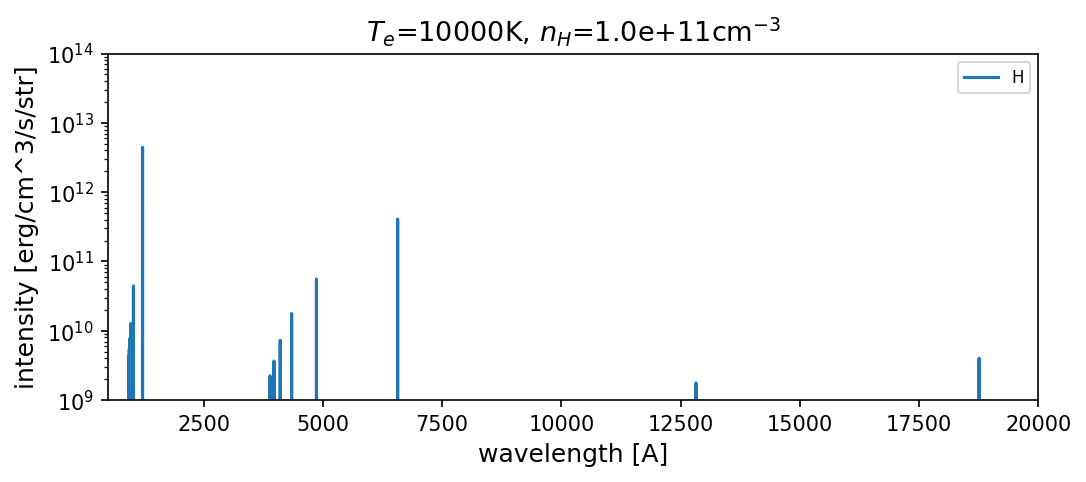

In [18]:
fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(l.wl_1D*1e8,l.prof_1D,label='H')
ax.set_ylim(1e9,1E14)
#ax.set_xlim(300, 12000)
#ax.set_xscale("log")
ax.set_xlim(500, 20000)
ax.set_yscale("log")
#ax.set_ylim(1e10, 5e13)
ax.set_xlabel("wavelength [A]", fontsize=12)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=12)
#plt.title("$T_e$={0:5.0f}K, $n_H$={1:5.1e}cm$^{{-3}}$, $n_e$={2:5.1e}cm$^{{-3}}$".format(Te, Nh, Ne),fontsize=13)
plt.title("$T_e$={0:5.0f}K, $n_H$={1:5.1e}cm$^{{-3}}$".format(Te, Nh),fontsize=13)
ax.legend(fontsize=8,ncol=1)
plt.show()